# ResNet50 X-ray classification

Training a binary classifier (healthy vs necrosis) on `.pt` X-rays rendered by `tazotron xray_dataset_from_ct` (folders `with_necro/` and `without_necro/`) with stratified K-fold cross-validation and a hold-out test split using `tazotron.nn.resnet50`.


## Imports & config

In [1]:
# ruff: noqa: I001
from __future__ import annotations

import random
import sys
from collections.abc import Sequence  # noqa: TC003
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "tazotron").exists():
            return candidate
    msg = "Could not locate the repository root containing src/tazotron"
    raise RuntimeError(msg)


PROJECT_ROOT = _find_repo_root(Path.cwd().resolve())
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

from tazotron.datasets.xray import XrayDataset
from tazotron.integrations.clearml import (
    CLEARML_ENABLED,
    finish_experiment,
    log_metrics,
    start_experiment,
    upload_model_artifact,
)
from tazotron.nn.metrics import compute_binary_metrics, metric_for_selection
from tazotron.nn.resnet50 import ResNet50


### Reproducibility

In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(mode=False)

set_seed(42)


### Paths and hyperparameters

In [3]:
DATA_ROOT = Path("../../.data/output_with_crop")
WITH_NECRO_DIR = DATA_ROOT / "with_necro"
WITHOUT_NECRO_DIR = DATA_ROOT / "without_necro"
ARTIFACTS_DIR = Path("../../reports/models")
TEST_RATIO = 0.10  # stratified hold-out
K_FOLDS = 5
FOLD_SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.3
NUM_WORKERS = 4

MODEL_NAME = "resnet50"
CLEARML_PROJECT_NAME = "Tazotron"
CLEARML_TASK_NAME = f"{MODEL_NAME}_xray_kfold"
CLEARML_TAGS = [MODEL_NAME, "xray", "kfold"]
BEST_FOLD_METRIC = "roc_auc"


## Device

In [4]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
PIN_MEMORY = device.type == "cuda"
EFFECTIVE_WORKERS = NUM_WORKERS if device.type == "cuda" else 0
device


device(type='mps')

## Dataset helpers

In [5]:
def load_samples(with_necro_dir: Path, without_necro_dir: Path) -> list[dict]:
    with_ds = XrayDataset(with_necro_dir)
    without_ds = XrayDataset(without_necro_dir)
    items: list[dict] = []
    for idx, path in enumerate(without_ds.paths):
        items.append({"dataset": without_ds, "index": idx, "label": 0, "necro": 0, "path": str(path)})
    for idx, path in enumerate(with_ds.paths):
        items.append({"dataset": with_ds, "index": idx, "label": 1, "necro": 1, "path": str(path)})
    return items

def stratified_split(items: Sequence[dict], test_ratio: float, seed: int = 42):
    rng = random.Random(seed)  # noqa: S311
    by_label: dict[int, list[dict]] = {0: [], 1: []}
    for item in items:
        by_label[item["label"]].append(item)
    for values in by_label.values():
        rng.shuffle(values)
    trainval: list[dict] = []
    test: list[dict] = []
    for values in by_label.values():
        n = len(values)
        n_test = max(1, round(n * test_ratio)) if n > 0 else 0
        test.extend(values[:n_test])
        trainval.extend(values[n_test:])
    return trainval, test

def stratified_kfold(items: Sequence[dict], k: int, seed: int = 42):
    rng = random.Random(seed)  # noqa: S311
    by_label: dict[int, list[dict]] = {0: [], 1: []}
    for item in items:
        by_label[item["label"]].append(item)
    for values in by_label.values():
        rng.shuffle(values)
    folds: list[list[dict]] = [[] for _ in range(k)]
    for values in by_label.values():
        for idx, item in enumerate(values):
            folds[idx % k].append(item)
    split_folds: list[tuple[list[dict], list[dict]]] = []
    for idx in range(k):
        val = folds[idx]
        train = [item for fold_idx, fold in enumerate(folds) if fold_idx != idx for item in fold]
        split_folds.append((train, val))
    return split_folds

class LabeledXrayDataset(Dataset):
    def __init__(self, entries: Sequence[dict], transform: transforms.Compose | None) -> None:
        self.entries = list(entries)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.entries)

    def __getitem__(self, idx: int):
        entry = self.entries[idx]
        tensor = entry["dataset"][entry["index"]]
        if self.transform is not None:
            tensor = self.transform(tensor)
        label = torch.tensor(entry["label"], dtype=torch.long)
        return {"image": tensor, "label": label, "necro": entry["necro"], "path": entry["path"]}



### Build splits

In [6]:
samples = load_samples(WITH_NECRO_DIR, WITHOUT_NECRO_DIR)
trainval_entries, test_entries = stratified_split(samples, test_ratio=TEST_RATIO, seed=FOLD_SEED)
folds = stratified_kfold(trainval_entries, k=K_FOLDS, seed=FOLD_SEED)
[(len(train), len(val)) for train, val in folds], len(test_entries)



([(680, 170), (680, 170), (680, 170), (680, 170), (680, 170)], 94)

### Transforms & loaders

In [7]:
def to_three_channels(img: torch.Tensor) -> torch.Tensor:
    return img.expand(3, -1, -1)

train_transform = transforms.Compose([
    transforms.Lambda(to_three_channels),
    transforms.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    transforms.RandomHorizontalFlip(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])
eval_transform = transforms.Compose([
    transforms.Lambda(to_three_channels),
    transforms.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

def build_loaders(train_entries, val_entries, test_entries):
    train_ds = LabeledXrayDataset(train_entries, train_transform)
    val_ds = LabeledXrayDataset(val_entries, eval_transform)
    test_ds = LabeledXrayDataset(test_entries, eval_transform)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=EFFECTIVE_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=EFFECTIVE_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=EFFECTIVE_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    return train_loader, val_loader, test_loader



## Model & optimizer

In [8]:
def build_model() -> ResNet50:
    return ResNet50(num_classes=2, dropout=DROPOUT).to(device)


def build_optimizer(model: torch.nn.Module):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    return criterion, optimizer, scheduler


## Train

In [9]:
def train_one_epoch(
    model: torch.nn.Module,
    loader: DataLoader,
    criterion: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
) -> dict:
    model.train()
    total_loss = 0.0
    total_items = 0
    all_targets: list[int] = []
    all_scores: list[float] = []

    for batch in tqdm(loader, desc="train", leave=False):
        inputs = batch["image"].to(device)
        targets = batch["label"].to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        probabilities = torch.softmax(outputs, dim=1)[:, 1]
        batch_size = inputs.size(0)
        total_loss += float(loss.item()) * batch_size
        total_items += batch_size
        all_targets.extend(targets.detach().cpu().tolist())
        all_scores.extend(probabilities.detach().cpu().tolist())

    average_loss = total_loss / max(1, total_items)
    return compute_binary_metrics(all_targets, all_scores, loss=average_loss)


def evaluate(
    model: torch.nn.Module,
    loader: DataLoader,
    criterion: torch.nn.Module,
    *,
    desc: str,
) -> dict:
    model.eval()
    total_loss = 0.0
    total_items = 0
    all_targets: list[int] = []
    all_scores: list[float] = []

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc, leave=False):
            inputs = batch["image"].to(device)
            targets = batch["label"].to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
            probabilities = torch.softmax(outputs, dim=1)[:, 1]

            batch_size = inputs.size(0)
            total_loss += float(loss.item()) * batch_size
            total_items += batch_size
            all_targets.extend(targets.detach().cpu().tolist())
            all_scores.extend(probabilities.detach().cpu().tolist())

    average_loss = total_loss / max(1, total_items)
    return compute_binary_metrics(all_targets, all_scores, loss=average_loss)


clearml_config = {
    "model_name": MODEL_NAME,
    "best_metric": BEST_FOLD_METRIC,
    "k_folds": K_FOLDS,
    "test_ratio": TEST_RATIO,
    "fold_seed": FOLD_SEED,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "dropout": DROPOUT,
    "num_workers": NUM_WORKERS,
}
run = start_experiment(
    config=clearml_config,
    task_name=CLEARML_TASK_NAME,
    project_name=CLEARML_PROJECT_NAME,
    tags=CLEARML_TAGS,
    enabled=CLEARML_ENABLED,
)

fold_histories: list[dict] = []
fold_results: list[dict] = []
best_val_score = float("-inf")
best_fold_checkpoint: Path | None = None

for fold_idx, (train_entries, val_entries) in enumerate(folds, start=1):
    train_loader, val_loader, test_loader = build_loaders(train_entries, val_entries, test_entries)
    model = build_model()
    criterion, optimizer, scheduler = build_optimizer(model)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_roc_auc": [],
        "val_roc_auc": [],
        "train_f1": [],
        "val_f1": [],
    }
    for epoch in range(EPOCHS):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer)
        val_metrics = evaluate(model, val_loader, criterion, desc=f"eval {fold_idx}")
        scheduler.step(val_metrics["loss"])

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_roc_auc"].append(train_metrics["roc_auc"])
        history["val_roc_auc"].append(val_metrics["roc_auc"])
        history["train_f1"].append(train_metrics["f1"])
        history["val_f1"].append(val_metrics["f1"])

        log_metrics(
            run,
            train_metrics,
            split="train",
            iteration=epoch + 1,
            fold=fold_idx,
            enabled=CLEARML_ENABLED,
        )
        log_metrics(
            run,
            val_metrics,
            split="val",
            iteration=epoch + 1,
            fold=fold_idx,
            enabled=CLEARML_ENABLED,
        )

        print(
            f"Fold {fold_idx}/{K_FOLDS} - Epoch {epoch + 1}/{EPOCHS} - "
            f"train_loss {train_metrics['loss']:.4f} roc_auc {train_metrics['roc_auc']:.3f} "
            f"f1 {train_metrics['f1']:.3f} | "
            f"val_loss {val_metrics['loss']:.4f} roc_auc {val_metrics['roc_auc']:.3f} "
            f"f1 {val_metrics['f1']:.3f}"
        )

    val_metrics = evaluate(model, val_loader, criterion, desc=f"val {fold_idx}")
    test_metrics = evaluate(model, test_loader, criterion, desc=f"test {fold_idx}")
    fold_histories.append(history)
    fold_payload = {
        "fold": fold_idx,
        "train_size": len(train_entries),
        "val_size": len(val_entries),
        "test_size": len(test_entries),
        "val": val_metrics,
        "test": test_metrics,
    }
    fold_results.append(fold_payload)

    log_metrics(
        run,
        val_metrics,
        split="val_final",
        iteration=fold_idx,
        fold=fold_idx,
        enabled=CLEARML_ENABLED,
    )
    log_metrics(
        run,
        test_metrics,
        split="test",
        iteration=fold_idx,
        fold=fold_idx,
        enabled=CLEARML_ENABLED,
    )

    current_val_score = metric_for_selection(val_metrics, BEST_FOLD_METRIC)
    if current_val_score > best_val_score:
        best_val_score = current_val_score
        ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
        best_fold_checkpoint = ARTIFACTS_DIR / f"{MODEL_NAME}_best_fold.pt"
        torch.save(model.state_dict(), best_fold_checkpoint)

best_fold_idx = max(
    range(1, len(fold_results) + 1),
    key=lambda position: metric_for_selection(fold_results[position - 1]["val"], BEST_FOLD_METRIC),
)
best_fold_payload = fold_results[best_fold_idx - 1]

fold_results


ClearML Task: created new task id=21c0ede3f32f404395fb57a1e5601e8c


Could not fetch GPU stats: NVML Shared Library Not Found


ClearML results page: https://app.clear.ml/projects/935808bf01ba43f79c0dae9c97110991/experiments/21c0ede3f32f404395fb57a1e5601e8c/output/log
ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


train:   0%|          | 0/85 [00:00<?, ?it/s]

eval 1:   0%|          | 0/22 [00:00<?, ?it/s]

...

Fold 5/5 - Epoch 10/10 - train_loss 0.6678 roc_auc 0.631 f1 0.482 | val_loss 0.7447 roc_auc 0.646 f1 0.604


val 5:   0%|          | 0/22 [00:00<?, ?it/s]

test 5:   0%|          | 0/12 [00:00<?, ?it/s]

[{'fold': 1,
  'train_size': 680,
  'val_size': 170,
  'test_size': 94,
  'val': {'loss': 0.6598777890205383,
   'accuracy': 0.6294117647058823,
   'precision': 0.6447368421052632,
   'recall': 0.5764705882352941,
   'f1': 0.6086956521739131,
   'roc_auc': 0.6601384083044983},
  'test': {'loss': 0.6544973076658046,
   'accuracy': 0.6382978723404256,
   'precision': 0.6511627906976745,
   'recall': 0.5957446808510638,
   'f1': 0.6222222222222222,
   'roc_auc': 0.6903576278859213}},
 {'fold': 2,
  'train_size': 680,
  'val_size': 170,
  'test_size': 94,
  'val': {'loss': 0.6551602237364825,
   'accuracy': 0.6411764705882353,
   'precision': 0.7142857142857143,
   'recall': 0.47058823529411764,
   'f1': 0.5673758865248227,
   'roc_auc': 0.6710726643598616},
  'test': {'loss': 0.6395741726489778,
   'accuracy': 0.6702127659574468,
   'precision': 0.75,
   'recall': 0.5106382978723404,
   'f1': 0.6075949367088608,
   'roc_auc': 0.7039384336803983}},
 {'fold': 3,
  'train_size': 680,
  'val_

### TASK STOPPED - USER ABORTED - STATUS CHANGED ###


## Learning curves

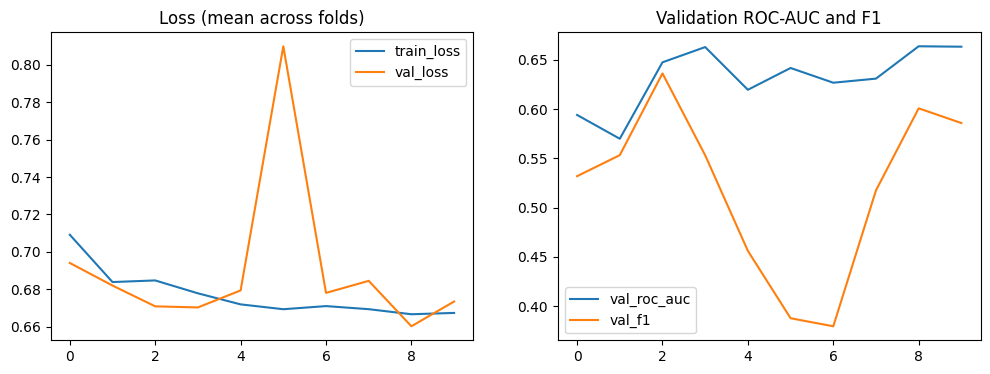

In [10]:
def mean_curve(key: str) -> list[float]:
    curves = torch.tensor([history[key] for history in fold_histories], dtype=torch.float32)
    return curves.mean(dim=0).tolist()


mean_train_loss = mean_curve("train_loss")
mean_val_loss = mean_curve("val_loss")
mean_val_roc_auc = mean_curve("val_roc_auc")
mean_val_f1 = mean_curve("val_f1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mean_train_loss, label="train_loss")
axes[0].plot(mean_val_loss, label="val_loss")
axes[0].set_title("Loss (mean across folds)")
axes[0].legend()
axes[1].plot(mean_val_roc_auc, label="val_roc_auc")
axes[1].plot(mean_val_f1, label="val_f1")
axes[1].set_title("Validation ROC-AUC and F1")
axes[1].legend()
plt.show()


## Test metrics

In [11]:
def summarize(metric: str, split: str) -> dict:
    values = torch.tensor([result[split][metric] for result in fold_results], dtype=torch.float32)
    return {"mean": values.mean().item(), "std": values.std(unbiased=False).item()}


summary = {
    "val_loss": summarize("loss", "val"),
    "val_accuracy": summarize("accuracy", "val"),
    "val_precision": summarize("precision", "val"),
    "val_recall": summarize("recall", "val"),
    "val_f1": summarize("f1", "val"),
    "val_roc_auc": summarize("roc_auc", "val"),
    "test_loss": summarize("loss", "test"),
    "test_accuracy": summarize("accuracy", "test"),
    "test_precision": summarize("precision", "test"),
    "test_recall": summarize("recall", "test"),
    "test_f1": summarize("f1", "test"),
    "test_roc_auc": summarize("roc_auc", "test"),
}

for metric_name, metric_stats in summary.items():
    log_metrics(
        run,
        {"mean": metric_stats["mean"], "std": metric_stats["std"]},
        split=metric_name,
        iteration=0,
        enabled=CLEARML_ENABLED,
    )

log_metrics(
    run,
    best_fold_payload["val"],
    split="best_val",
    iteration=best_fold_idx,
    fold=best_fold_idx,
    enabled=CLEARML_ENABLED,
)
best_checkpoint_metrics = {
    metric_name: best_fold_payload["val"][metric_name]
    for metric_name in ("accuracy", "precision", "recall", "f1", "roc_auc")
}
log_metrics(
    run,
    best_checkpoint_metrics,
    split="best_checkpoint_metrics",
    iteration=best_fold_idx,
    enabled=CLEARML_ENABLED,
)
log_metrics(
    run,
    best_fold_payload["test"],
    split="best_test",
    iteration=best_fold_idx,
    fold=best_fold_idx,
    enabled=CLEARML_ENABLED,
)

if best_fold_checkpoint is not None:
    upload_model_artifact(
        run,
        alias="best_model_state_dict",
        path=best_fold_checkpoint,
        enabled=CLEARML_ENABLED,
    )

finish_experiment(run, enabled=CLEARML_ENABLED)
summary


████████████████████████████████ 100% | 30.40/30.4 MB [00:02<00:00, 10.66MB/s]: 


{'val_loss': {'mean': 0.6733921766281128, 'std': 0.03581995144486427},
 'val_accuracy': {'mean': 0.6223529577255249, 'std': 0.019115382805466652},
 'val_precision': {'mean': 0.6506689786911011, 'std': 0.03546103090047836},
 'val_recall': {'mean': 0.5388235449790955, 'std': 0.06630119681358337},
 'val_f1': {'mean': 0.5859053730964661, 'std': 0.03627185896039009},
 'val_roc_auc': {'mean': 0.6634048223495483, 'std': 0.009800957515835762},
 'test_loss': {'mean': 0.6491731405258179, 'std': 0.029334766790270805},
 'test_accuracy': {'mean': 0.6510637998580933, 'std': 0.026403557509183884},
 'test_precision': {'mean': 0.6897585391998291, 'std': 0.06507578492164612},
 'test_recall': {'mean': 0.5744680762290955, 'std': 0.052116796374320984},
 'test_f1': {'mean': 0.6218036413192749, 'std': 0.010098112747073174},
 'test_roc_auc': {'mean': 0.6974197030067444, 'std': 0.02180010825395584}}